#### Ejercicio 20 de agosto
Crear un grid (Maze) 15x15 con 5 obstaculos ubicados aleatoriamente.

Con inicio y fin ubicados aleatoriamente

Con 10 iteraciones, mostrar la convergencia (plot) para el método y para el método de valores

Graficar recompensa

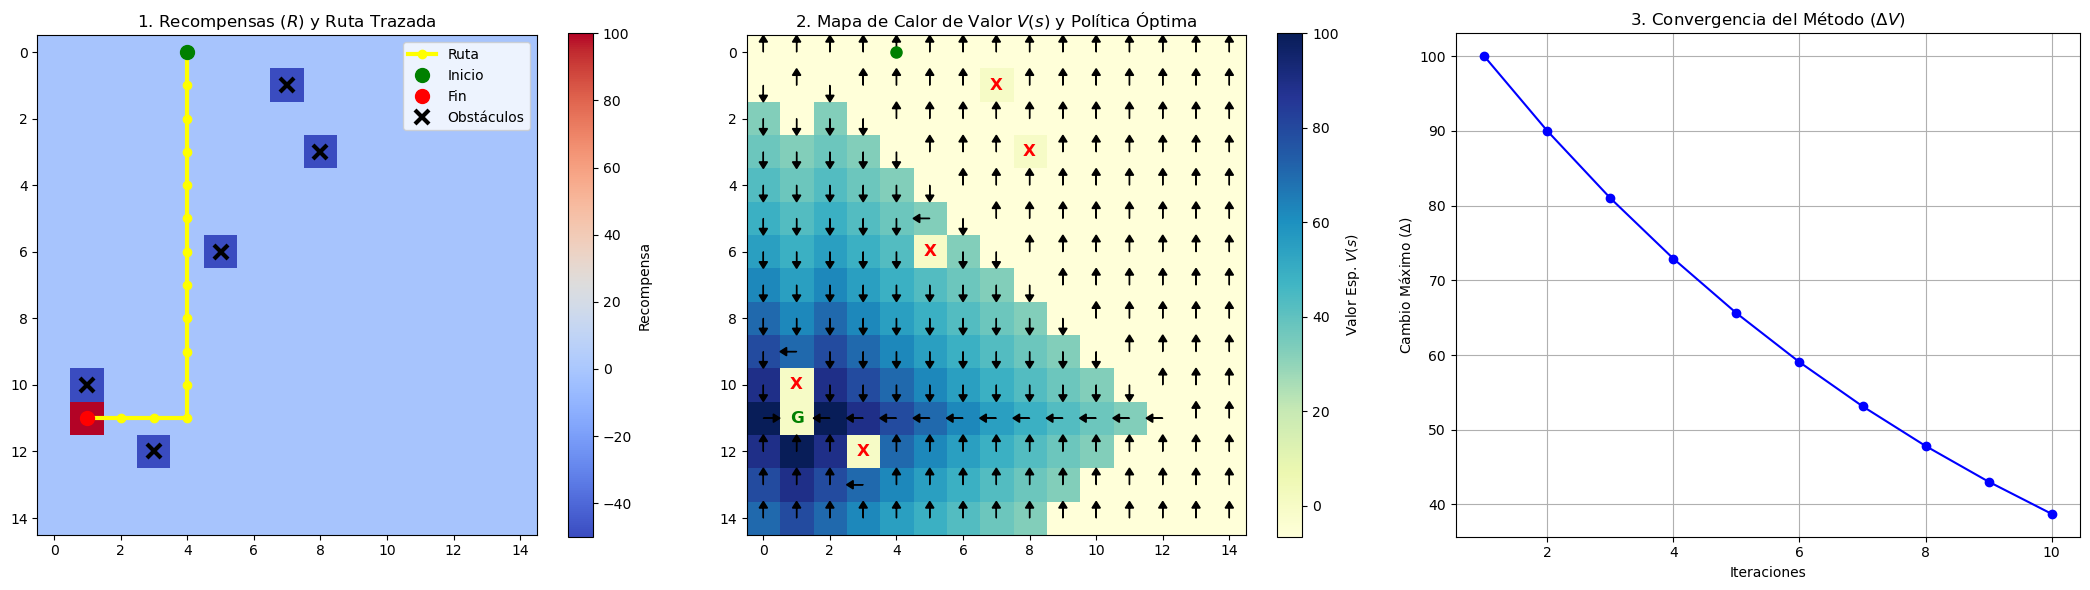

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Configuración del Entorno GridWorld 15x15
GRID_SIZE = 15
NUM_OBSTACLES = 5
ITERATIONS = 10
GAMMA = 0.9
REWARD_GOAL = 100.0
REWARD_STEP = -1.0
REWARD_OBSTACLE = -50.0

# Posiciones aleatorias para inicio, fin y obstáculos
all_positions = [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)]
selected = random.sample(all_positions, NUM_OBSTACLES + 2)

start_pos = selected[0]
goal_pos = selected[1]
obstacles = set(selected[2:])

# Matriz de Recompensas
R = np.full((GRID_SIZE, GRID_SIZE), REWARD_STEP)
for obs in obstacles:
    R[obs] = REWARD_OBSTACLE
R[goal_pos] = REWARD_GOAL

# Acciones: Arriba (-1,0), Abajo (1,0), Izquierda (0,-1), Derecha (0,1)
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
ACTION_VECTORS = [(-0.3, 0), (0.3, 0), (0, -0.3), (0, 0.3)]  # (dy, dx) para vectores visuales

def get_next_state(r, c, action):
    dr, dc = action
    nr, nc = r + dr, c + dc
    if 0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE and (nr, nc) not in obstacles:
        return nr, nc
    return r, c

# 2. Iteración de Valores
def value_iteration(iterations=10):
    V = np.zeros((GRID_SIZE, GRID_SIZE))
    deltas = []
    
    for _ in range(iterations):
        V_next = np.copy(V)
        max_delta = 0.0
        
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                if (r, c) == goal_pos or (r, c) in obstacles:
                    continue
                
                action_values = [R[get_next_state(r, c, a)] + GAMMA * V[get_next_state(r, c, a)] for a in ACTIONS]
                best_value = max(action_values)
                max_delta = max(max_delta, abs(best_value - V[r, c]))
                V_next[r, c] = best_value
                
        V = V_next
        deltas.append(max_delta)
        
    return V, deltas

# 3. Extracción de la Política Óptima y la Ruta
def extract_policy(V):
    policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) == goal_pos or (r, c) in obstacles:
                continue
            best_action = np.argmax([R[get_next_state(r, c, a)] + GAMMA * V[get_next_state(r, c, a)] for a in ACTIONS])
            policy[r, c] = best_action
    return policy

def extract_path(V, max_steps=100):
    path = [start_pos]
    curr = start_pos
    
    for _ in range(max_steps):
        if curr == goal_pos:
            break
        best_val = -float('inf')
        best_next = curr
        
        for a in ACTIONS:
            nr, nc = get_next_state(curr[0], curr[1], a)
            if (nr, nc) not in path or (nr, nc) == goal_pos:
                val = R[nr, nc] + GAMMA * V[nr, nc]
                if val > best_val:
                    best_val = val
                    best_next = (nr, nc)
                    
        if best_next == curr:
            break
        curr = best_next
        path.append(curr)
        
    return path

# Ejecución
V, deltas = value_iteration(ITERATIONS)
policy = extract_policy(V)
path = extract_path(V)

# 4. Visualización con Mapa de Calor de Política Óptima
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Gráfico 1: Recompensas y Ruta Traza
im0 = axes[0].imshow(R, cmap='coolwarm', origin='upper')
axes[0].set_title("1. Recompensas ($R$) y Ruta Trazada")
if len(path) > 1:
    path_y, path_x = zip(*path)
    axes[0].plot(path_x, path_y, color='yellow', linewidth=3, marker='o', label='Ruta')
axes[0].plot(start_pos[1], start_pos[0], 'go', markersize=10, label='Inicio')
axes[0].plot(goal_pos[1], goal_pos[0], 'ro', markersize=10, label='Fin')
obs_x = [c for r, c in obstacles]
obs_y = [r for r, c in obstacles]
axes[0].plot(obs_x, obs_y, 'kx', markersize=10, markeredgewidth=3, label='Obstáculos')
axes[0].legend(loc='upper right')
fig.colorbar(im0, ax=axes[0], label='Recompensa')

# Gráfico 2: Mapa de Calor de Valores V(s) + Flechas de Política π(s)
im1 = axes[1].imshow(V, cmap='YlGnBu', origin='upper')
axes[1].set_title("2. Mapa de Calor de Valor $V(s)$ y Política Óptima")

# Dibujar flechas de acción óptima en cada celda
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        if (r, c) == goal_pos:
            axes[1].text(c, r, 'G', color='green', ha='center', va='center', weight='bold', fontsize=12)
        elif (r, c) in obstacles:
            axes[1].text(c, r, 'X', color='red', ha='center', va='center', weight='bold', fontsize=12)
        else:
            action_idx = policy[r, c]
            dy, dx = ACTION_VECTORS[action_idx]
            axes[1].arrow(c, r, dx, dy, head_width=0.25, head_length=0.2, fc='black', ec='black')

axes[1].plot(start_pos[1], start_pos[0], 'go', markersize=8)
fig.colorbar(im1, ax=axes[1], label='Valor Esp. $V(s)$')

# Gráfico 3: Convergencia de Value Iteration
axes[2].plot(range(1, ITERATIONS + 1), deltas, 'o-', color='blue')
axes[2].set_title("3. Convergencia del Método ($\Delta V$)")
axes[2].set_xlabel("Iteraciones")
axes[2].set_ylabel("Cambio Máximo ($\Delta$)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

Reinforcement learning

El Q-Learning es un algoritmo de Aprendizaje por Refuerzo libre de modelo. A diferencia de la Iteración de Valores o de Políticas, el agente no necesita conocer a priori la dinámica del entorno ni la matriz de transición. En su lugar, aprende interactuando directamente mediante un proceso de ensayo y error.1. ¿Cómo funciona el Q-Learning?El objetivo es aprender una función de valor de acción $Q(s, a)$, que representa la recompensa acumulada esperada si el agente toma la acción $a$ en el estado $s$ y, a partir de ahí, sigue la política óptima.

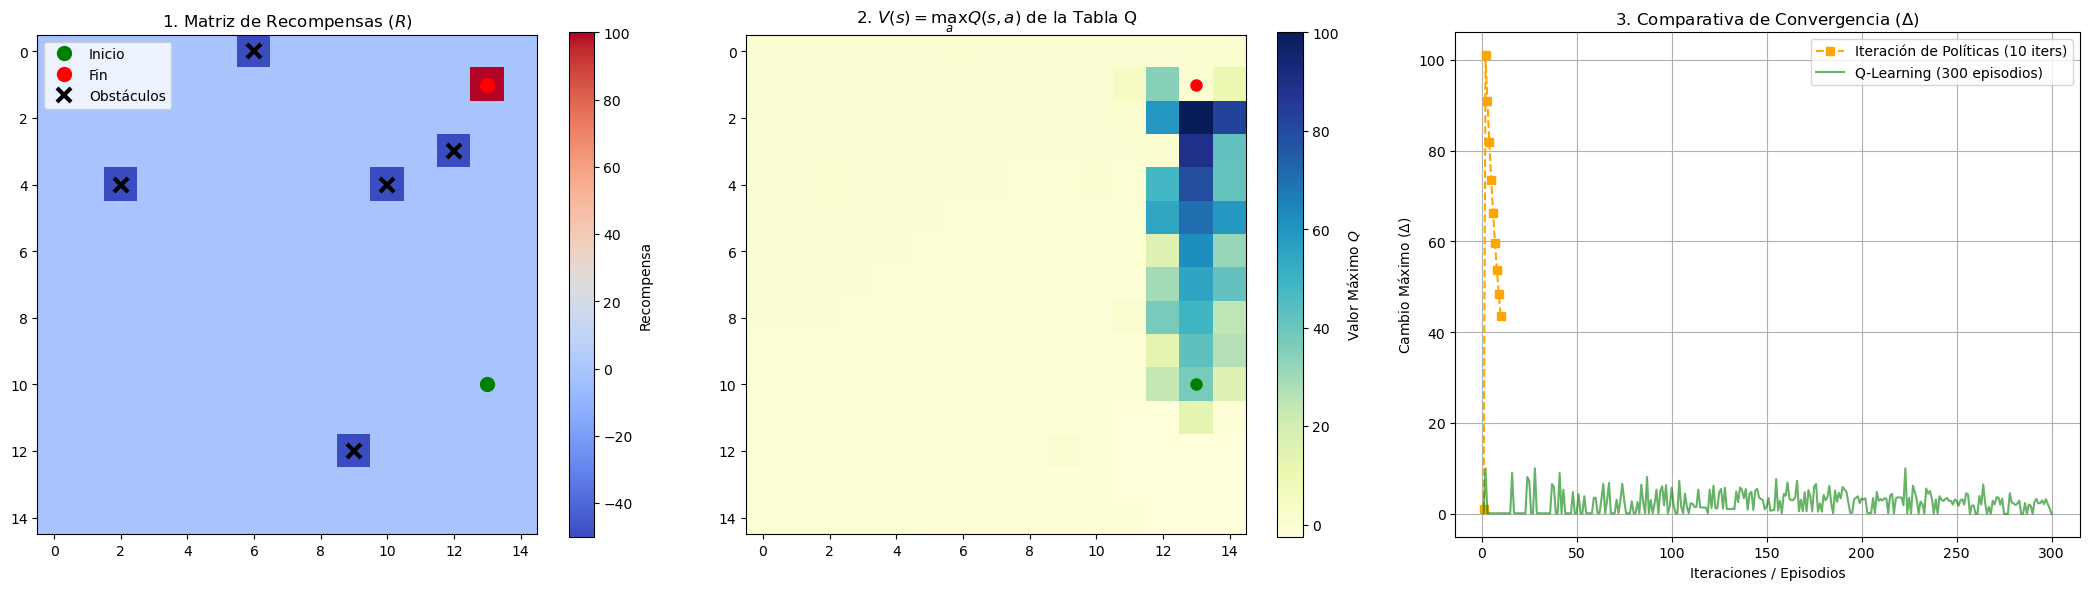

Estructura de la Tabla Q: (225, 4) (Estados x Acciones)

Muestra de las primeras 5 filas de la Tabla Q (Estados 0 a 4):
Estado | Arriba   | Abajo    | Izquierda| Derecha  
--------------------------------------------------
S_000  |    -0.20 |    -0.20 |    -0.20 |    -0.20
S_001  |    -0.29 |    -0.20 |    -0.20 |    -0.20
S_002  |    -0.20 |    -0.20 |    -0.20 |    -0.22
S_003  |    -0.30 |    -0.30 |    -0.20 |    -0.30
S_004  |    -0.29 |    -0.30 |    -0.30 |    -0.21


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Configuración del Entorno GridWorld 15x15
GRID_SIZE = 15
NUM_STATES = GRID_SIZE * GRID_SIZE
NUM_OBSTACLES = 5
GAMMA = 0.9
ALPHA = 0.1         # Tasa de aprendizaje para Q-Learning
EPSILON = 0.2       # Exploración para Q-Learning
EPISODES = 300      # Episodios de entrenamiento de Q-Learning
STEPS_PER_EPISODE = 100

REWARD_GOAL = 100.0
REWARD_STEP = -1.0
REWARD_OBSTACLE = -50.0

# Fijar semilla para reproducibilidad
np.random.seed(42)
random.seed(42)

# Mapeo de coordenadas (r, c) a índice de estado unidimensional (0..224)
def state_to_idx(r, c):
    return r * GRID_SIZE + c

def idx_to_state(idx):
    return idx // GRID_SIZE, idx % GRID_SIZE

# Posiciones aleatorias
all_positions = [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)]
selected = random.sample(all_positions, NUM_OBSTACLES + 2)

start_pos = selected[0]
goal_pos = selected[1]
obstacles = set(selected[2:])

start_idx = state_to_idx(*start_pos)
goal_idx = state_to_idx(*goal_pos)
obstacle_idxs = {state_to_idx(r, c) for r, c in obstacles}

# Matriz de Recompensas R (Formato 15x15)
R = np.full((GRID_SIZE, GRID_SIZE), REWARD_STEP)
for obs in obstacles:
    R[obs] = REWARD_OBSTACLE
R[goal_pos] = REWARD_GOAL

ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # 0: Arriba, 1: Abajo, 2: Izquierda, 3: Derecha
NUM_ACTIONS = len(ACTIONS)

def get_next_state(r, c, action_idx):
    dr, dc = ACTIONS[action_idx]
    nr, nc = r + dr, c + dc
    if 0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE and (nr, nc) not in obstacles:
        return nr, nc
    return r, c

# 2. Algoritmo Q-Learning
def train_q_learning(episodes=300):
    # Tabla Q inicializada en ceros: Matriz (225 x 4)
    Q_table = np.zeros((NUM_STATES, NUM_ACTIONS))
    deltas_per_episode = []
    
    for episode in range(episodes):
        r, c = start_pos
        curr_idx = state_to_idx(r, c)
        max_delta = 0.0
        
        for _ in range(STEPS_PER_EPISODE):
            if (r, c) == goal_pos:
                break
                
            # Política epsilon-greedy
            if random.random() < EPSILON:
                action_idx = random.randint(0, NUM_ACTIONS - 1)
            else:
                action_idx = np.argmax(Q_table[curr_idx])
                
            nr, nc = get_next_state(r, c, action_idx)
            next_idx = state_to_idx(nr, nc)
            reward = R[nr, nc]
            
            # Actualización TD
            old_q = Q_table[curr_idx, action_idx]
            max_future_q = np.max(Q_table[next_idx]) if (nr, nc) != goal_pos else 0.0
            new_q = old_q + ALPHA * (reward + GAMMA * max_future_q - old_q)
            
            Q_table[curr_idx, action_idx] = new_q
            max_delta = max(max_delta, abs(new_q - old_q))
            
            r, c = nr, nc
            curr_idx = next_idx
            
        deltas_per_episode.append(max_delta)
        
    return Q_table, deltas_per_episode

# 3. Iteración de Políticas (Policy Iteration)
def policy_iteration(iterations=10):
    V = np.zeros((GRID_SIZE, GRID_SIZE))
    policy = np.random.randint(0, NUM_ACTIONS, size=(GRID_SIZE, GRID_SIZE))
    deltas = []
    
    for _ in range(iterations):
        V_next = np.copy(V)
        max_delta = 0.0
        
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                if (r, c) == goal_pos or (r, c) in obstacles:
                    continue
                a = ACTIONS[policy[r, c]]
                nr, nc = get_next_state(r, c, policy[r, c])
                val = R[nr, nc] + GAMMA * V[nr, nc]
                max_delta = max(max_delta, abs(val - V[r, c]))
                V_next[r, c] = val
                
        V = V_next
        deltas.append(max_delta)
        
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                if (r, c) == goal_pos or (r, c) in obstacles:
                    continue
                best_action = np.argmax([R[get_next_state(r, c, a_idx)] + GAMMA * V[get_next_state(r, c, a_idx)] for a_idx in range(NUM_ACTIONS)])
                policy[r, c] = best_action
                
    return V, deltas

# Ejecución
Q_table, q_deltas = train_q_learning(EPISODES)
_, pi_deltas = policy_iteration(10)

# Extraer V_Q(s) maximizando sobre las acciones de la Tabla Q
V_from_Q = np.max(Q_table, axis=1).reshape((GRID_SIZE, GRID_SIZE))

# 4. Visualización
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Subplot 1: Matriz de Recompensas R
im0 = axes[0].imshow(R, cmap='coolwarm', origin='upper')
axes[0].set_title("1. Matriz de Recompensas ($R$)")
axes[0].plot(start_pos[1], start_pos[0], 'go', markersize=10, label='Inicio')
axes[0].plot(goal_pos[1], goal_pos[0], 'ro', markersize=10, label='Fin')
obs_x = [c for r, c in obstacles]
obs_y = [r for r, c in obstacles]
axes[0].plot(obs_x, obs_y, 'kx', markersize=10, markeredgewidth=3, label='Obstáculos')
axes[0].legend()
fig.colorbar(im0, ax=axes[0], label='Recompensa')

# Subplot 2: Mapa de calor $V(s)$ derivado de la Tabla Q
im1 = axes[1].imshow(V_from_Q, cmap='YlGnBu', origin='upper')
axes[1].set_title("2. $V(s) = \max_a Q(s,a)$ de la Tabla Q")
axes[1].plot(start_pos[1], start_pos[0], 'go', markersize=8)
axes[1].plot(goal_pos[1], goal_pos[0], 'ro', markersize=8)
fig.colorbar(im1, ax=axes[1], label='Valor Máximo $Q$')

# Subplot 3: Comparativa de Convergencia
axes[2].plot(range(1, 11), pi_deltas[:10], 's--', color='orange', label='Iteración de Políticas (10 iters)')
axes[2].plot(range(1, EPISODES + 1), q_deltas, '-', color='green', alpha=0.6, label='Q-Learning (300 episodios)')
axes[2].set_title("3. Comparativa de Convergencia ($\Delta$)")
axes[2].set_xlabel("Iteraciones / Episodios")
axes[2].set_ylabel("Cambio Máximo ($\Delta$)")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

# Muestra parcial de la Tabla Q (primeros 5 estados)
print(f"Estructura de la Tabla Q: {Q_table.shape} (Estados x Acciones)")
print("\nMuestra de las primeras 5 filas de la Tabla Q (Estados 0 a 4):")
print("Estado | Arriba   | Abajo    | Izquierda| Derecha  ")
print("-" * 50)
for idx in range(5):
    row = Q_table[idx]
    print(f"S_{idx:03d}  | {row[0]:8.2f} | {row[1]:8.2f} | {row[2]:8.2f} | {row[3]:8.2f}")